In [3]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.formula.api import ols
import matplotlib.pyplot as plt
import scipy.stats as stats

In [9]:
#dados = pd.read_csv(r"G:\Meu Drive\Doutorado_Esalq\estatistica_exp\arquivos\dados_milho.csv", sep=",")
dados = pd.read_csv(r"/Users/lucaslima/Library/CloudStorage/GoogleDrive-lucas8888.santi@gmail.com/O meu disco/Doutorado_Esalq/estatistica_exp/arquivos/dados_milho.csv", sep=",")
dados

,dose_N,produtividade
0,0,3100
1,0,3200
2,0,3050
3,0,3150
4,50,5500
5,50,5650
6,50,5450
7,50,5600
8,100,7800
9,100,7950


In [8]:
modelo_anova = ols('produtividade ~ C(dose_N)', data=dados).fit()

- extraindo residuos

In [9]:
residuos = modelo_anova.resid

### a) Teste estatístico: Shapiro-Wilk
#### H₀: Os dados seguem uma distribuição normal.

In [10]:
shapiro_test = stats.shapiro(residuos)
print(f"--- 1. Teste de Normalidade (Shapiro-Wilk) ---")
print(f"Estatística do teste: {shapiro_test.statistic:.4f}")
print(f"P-valor: {shapiro_test.pvalue:.4f}\n")

--- 1. Teste de Normalidade (Shapiro-Wilk) ---
Estatística do teste: 0.9292
P-valor: 0.1488



# De acordo com o teste de Shapiro-Wilk, os resíduos podem ser considerados normais. Assim, atendendo as pressupossições da __ANOVA__.

### b) Análise gráfica: Gráfico Q-Q (Quantil-Quantil)

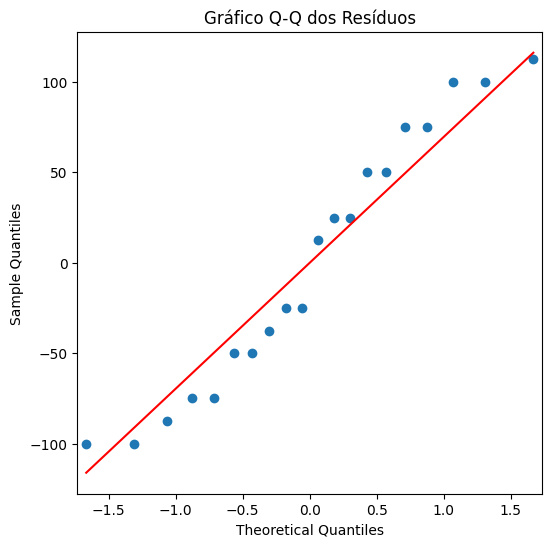

In [11]:

fig, ax = plt.subplots(figsize=(6, 6))
sm.qqplot(residuos, line='s', ax=ax)
ax.set_title('Gráfico Q-Q dos Resíduos')
plt.show()

---
### --- 3. Verificação da Pressuposição 2: HOMOGENEIDADE DAS VARIÂNCIAS ---

#### a) Teste estatístico: Teste de Levene
#### H₀: As variâncias são iguais entre os grupos (tratamentos).
#### Precisamos agrupar os resíduos por tratamento

In [13]:
grupos_residuos = [residuos[dados['dose_N'] == dose] for dose in dados['dose_N'].unique()]
levene_test = stats.levene(*grupos_residuos)
print(f"--- 2. Teste de Homogeneidade de Variâncias (Levene) ---")
print(f"Estatística do teste: {levene_test.statistic:.4f}")
print(f"P-valor: {levene_test.pvalue:.4f}\n")

--- 2. Teste de Homogeneidade de Variâncias (Levene) ---
Estatística do teste: 0.5556
P-valor: 0.6982



# De acordo com o teste de homogeneidade de variâncias de Levene, os resíduos podem ser considerados homogêneos. Assim, atendendo as pressupossições da __ANOVA__.

### b) Análise gráfica: Gráfico de Resíduos vs. Valores Ajustados

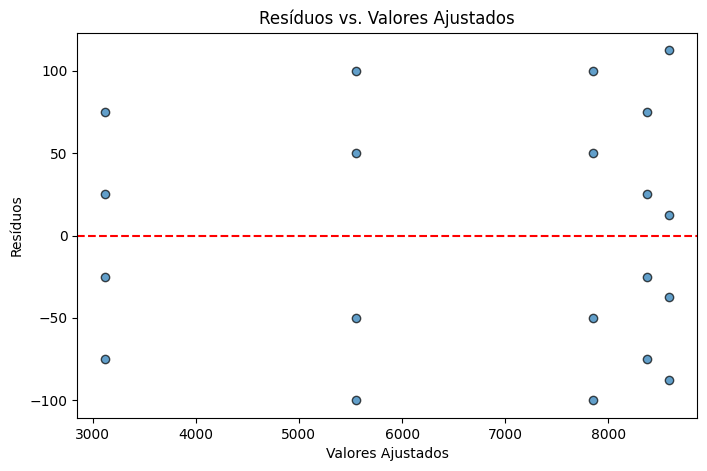

In [15]:
valores_ajustados = modelo_anova.fittedvalues
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(valores_ajustados, residuos, edgecolors='k', alpha=0.7)
ax.axhline(y=0, color='r', linestyle='--')
ax.set_title('Resíduos vs. Valores Ajustados')
ax.set_xlabel('Valores Ajustados')
ax.set_ylabel('Resíduos')
plt.show()

In [16]:
# --- 4. Verificação da Pressuposição 3: INDEPENDÊNCIA DOS RESÍDUOS ---
print(f"--- 3. Análise da Independência dos Resíduos ---")
print("A independência é geralmente garantida pela casualização do experimento.")
print("A análise gráfica (Resíduos vs. Valores Ajustados) nos ajuda a verificar se há algum padrão evidente.")
print("Uma nuvem de pontos aleatória, como a observada, sugere que os resíduos são independentes.\n")

--- 3. Análise da Independência dos Resíduos ---
A independência é geralmente garantida pela casualização do experimento.
A análise gráfica (Resíduos vs. Valores Ajustados) nos ajuda a verificar se há algum padrão evidente.
Uma nuvem de pontos aleatória, como a observada, sugere que os resíduos são independentes.

